# 01 — Non-Personalized Recommender
**Contributors:** Jimena Navarro - Tessa Correig - Sofía Serantes - Paula Evangelista - Bernarda Andrade - Daniel Teixidor

**Group 2 | Inside Airbnb Madrid — Apartment Recommendation System**

This notebook covers data loading and cleaning, exploratory analysis across 8 visualisations, and the non-personalised recommender built in three variants: Raw Average, Bayesian Average, and Value-Weighted. It also includes neighbourhood-filtered recommendations and evaluation against RMSE, MAE, Precision@10, Recall@10 and NDCG@10.

**Dataset:** Inside Airbnb Madrid — `listings.csv.gz` + `reviews.csv` in `data/`


In [1]:
# Google Colab: mount Drive and set data paths
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/recommender_project/data'
    print('✓ Google Drive mounted')
except ImportError:
    DATA_DIR = 'data'
    print('✓ Running locally — using data/ folder')

LISTINGS_PATH = os.path.join(DATA_DIR, 'listings.csv.gz')
REVIEWS_PATH  = os.path.join(DATA_DIR, 'reviews.csv')
print(f'Listings : {LISTINGS_PATH}')
print(f'Reviews  : {REVIEWS_PATH}')


Mounted at /content/drive
✓ Google Drive mounted
Listings : /content/drive/MyDrive/recommender_project/data/listings.csv.gz
Reviews  : /content/drive/MyDrive/recommender_project/data/reviews.csv


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker, seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('✓ Libraries loaded')

✓ Libraries loaded


In [3]:
# Load files

listings = pd.read_csv(LISTINGS_PATH, low_memory=False)
reviews  = pd.read_csv(REVIEWS_PATH,     low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])

print(f'Listings : {len(listings):,} rows × {listings.shape[1]} columns')
print(f'Reviews  : {len(reviews):,} rows')

# Clean price
listings['price_clean'] = (
    listings['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)
# Remove extreme outliers (> €2,000/night)
listings = listings[listings['price_clean'].isna() | (listings['price_clean'] <= 2000)].copy()

# Clean review scores
score_cols = [
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
    'review_scores_value', 'review_scores_checkin', 'review_scores_communication'
]
for col in score_cols:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

# Impute missing ratings: neighbourhood mean, then global mean
listings['review_scores_rating'] = (
    listings.groupby('neighbourhood_cleansed')['review_scores_rating']
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(listings['review_scores_rating'].mean())
)
for col in score_cols[1:]:
    listings[col] = listings[col].fillna(4.5)

# Boolean flags
listings['is_superhost']    = (listings['host_is_superhost'] == 't').astype(int)
listings['is_instant_book'] = (listings['instant_bookable']  == 't').astype(int)

# Host rate columns (strip % → float 0–1)
for col in ['host_response_rate', 'host_acceptance_rate']:
    listings[col] = (
        pd.to_numeric(listings[col].astype(str).str.replace('%', ''), errors='coerce')
        .fillna(80) / 100
    )

# Numeric conversions
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews',
            'host_listings_count', 'minimum_nights']:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

listings['number_of_reviews'] = listings['number_of_reviews'].fillna(0)
listings['accommodates']      = listings['accommodates'].fillna(2)
listings['minimum_nights']    = listings['minimum_nights'].fillna(1).clip(1, 365)
listings['bedrooms']          = listings['bedrooms'].fillna(1)
listings['price_clean']       = listings['price_clean'].fillna(listings['price_clean'].median())

# Host seniority in years
listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')
listings['host_years'] = (
    (pd.Timestamp('2025-01-01') - listings['host_since']).dt.days / 365.25
).clip(0, 20).fillna(3)

# Amenity binary flags
amenity_map = {
    'wifi'    : r'wifi|wi-fi',
    'kitchen' : r'kitchen',
    'ac'      : r'air conditioning|air-conditioning',
    'heating' : r'heating',
    'washer'  : r'washer|washing machine',
    'tv'      : r'\btv\b|television',
    'parking' : r'parking|garage',
    'elevator': r'elevator|lift',
    'gym'     : r'\bgym\b|fitness center',
    'pets'    : r'pets allowed',
}
amenities_str = listings['amenities'].fillna('').str.lower()
for name, pattern in amenity_map.items():
    listings[f'am_{name}'] = amenities_str.str.contains(pattern, regex=True).astype(int)

# Bayesian average (used across all recommenders)
C = listings['review_scores_rating'].mean()   # global mean
m = 50                                         # regularisation threshold
listings['bayesian_avg'] = (
    (listings['number_of_reviews'] / (listings['number_of_reviews'] + m))
    * listings['review_scores_rating']
    + (m / (listings['number_of_reviews'] + m)) * C
)

# Train / test temporal split
SPLIT_DATE = pd.Timestamp('2024-07-01')
train_rev = reviews[reviews['date'] <  SPLIT_DATE].copy()
test_rev  = reviews[reviews['date'] >= SPLIT_DATE].copy()

print(f'\nAfter cleaning: {len(listings):,} listings')
print(f'Price range   : €{listings["price_clean"].min():.0f} – €{listings["price_clean"].max():.0f}')
print(f'Global avg C  : {C:.4f}')
print(f'Train reviews : {len(train_rev):,}  |  Test: {len(test_rev):,}')
print(f'\n✓ Cleaning complete — all derived columns ready.')


Listings : 25,000 rows × 79 columns
Reviews  : 1,275,992 rows

After cleaning: 24,958 listings
Price range   : €8 – €1988
Global avg C  : 4.6291
Train reviews : 862,549  |  Test: 413,443

✓ Cleaning complete — all derived columns ready.


## 2. Exploratory Data Analysis

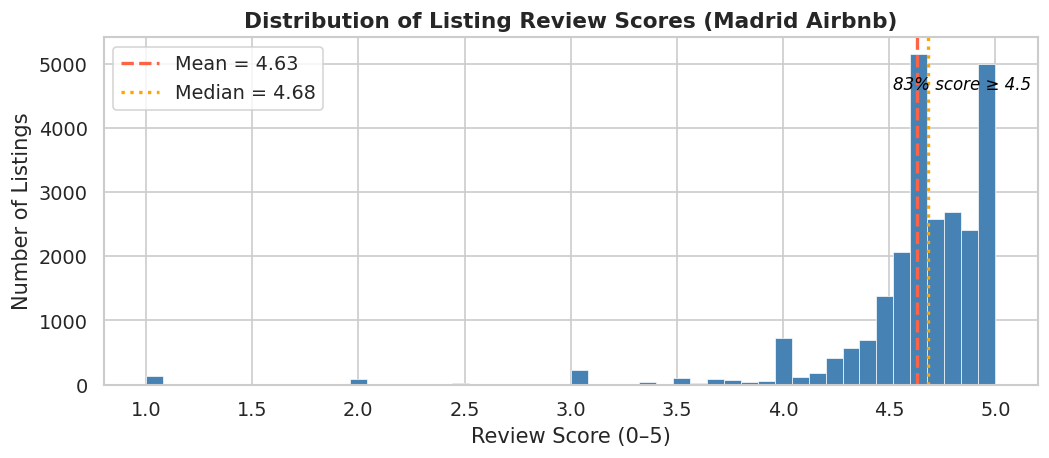

In [4]:
# EDA Fig 1: Ratings Distribution
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(listings['review_scores_rating'].dropna(), bins=50,
        color='steelblue', edgecolor='white', linewidth=0.4)

mean_r = listings['review_scores_rating'].mean()
med_r  = listings['review_scores_rating'].median()
ax.axvline(mean_r, color='tomato',  lw=2, linestyle='--', label=f'Mean = {mean_r:.2f}')
ax.axvline(med_r,  color='orange',  lw=2, linestyle=':',  label=f'Median = {med_r:.2f}')

pct_above45 = (listings['review_scores_rating'] >= 4.5).mean() * 100
ax.text(4.52, ax.get_ylim()[1] * 0.85, f'{pct_above45:.0f}% score ≥ 4.5',
        color='black', fontsize=10, fontstyle='italic')

ax.set_title('Distribution of Listing Review Scores (Madrid Airbnb)', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score (0–5)')
ax.set_ylabel('Number of Listings')
ax.legend()
plt.tight_layout()
plt.savefig('figures/01_ratings_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The distribution is heavily left-skewed, with over 83% of listings scoring 4.5 or above out of 5. This ceiling effect is a challenge for any rating-based recommender: a listing at 4.6 and one at 4.9 look nearly identical numerically, but the difference could matter a lot to a user trying to choose. It also means raw averages are unreliable for listings with few reviews, one bad review can unfairly drag down a good property, and one lucky 5-star review can inflate a poor one. That is the motivation for using Bayesian regularisation in Section 3.


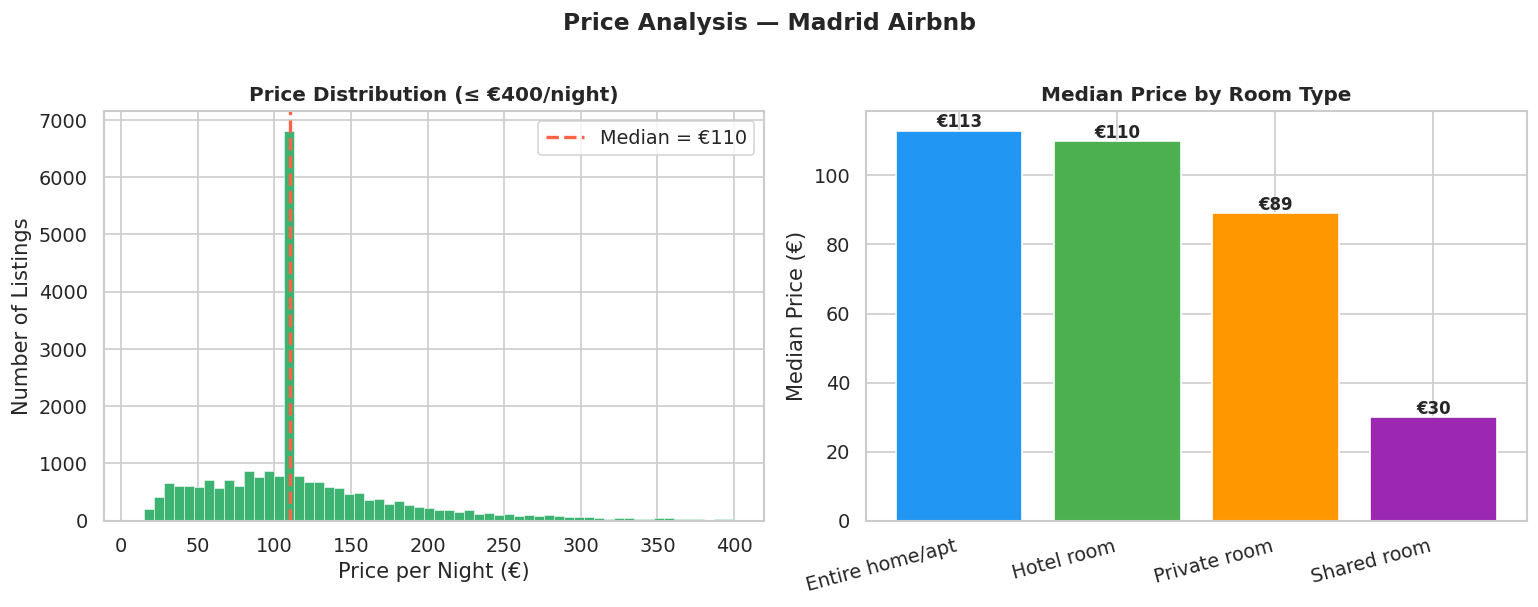

In [5]:
# EDA Fig 2: Price Distribution & Price by Room Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: price histogram (capped at €400)
ax = axes[0]
price_cap = listings['price_clean'].dropna()
price_cap = price_cap[price_cap <= 400]
ax.hist(price_cap, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.axvline(price_cap.median(), color='tomato', lw=2, linestyle='--',
           label=f'Median = €{price_cap.median():.0f}')
ax.set_title('Price Distribution (≤ €400/night)', fontsize=12, fontweight='bold')
ax.set_xlabel('Price per Night (€)')
ax.set_ylabel('Number of Listings')
ax.legend()

# Right: median price by room type
ax = axes[1]
room_price = listings.groupby('room_type')['price_clean'].median().sort_values(ascending=False)
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.bar(range(len(room_price)), room_price.values,
              color=colors_bar[:len(room_price)], edgecolor='white')
for bar, val in zip(bars, room_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'€{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(room_price)))
ax.set_xticklabels(room_price.index, rotation=15, ha='right')
ax.set_title('Median Price by Room Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Price (€)')

plt.suptitle('Price Analysis — Madrid Airbnb', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Prices are right-skewed with a median of €110 per night. The long right tail comes from a small number of luxury properties, removing listings above €2,000 cuts fewer than 50. Entire homes are more expensive (median around €125) than private rooms (median around €55), which makes sense given the different types of guests each attracts. This price gap will matter in the content-based recommender (Notebook 03) and in the context-aware model, where business travellers tend to book private rooms and higuer income groups tend to book entire flats.


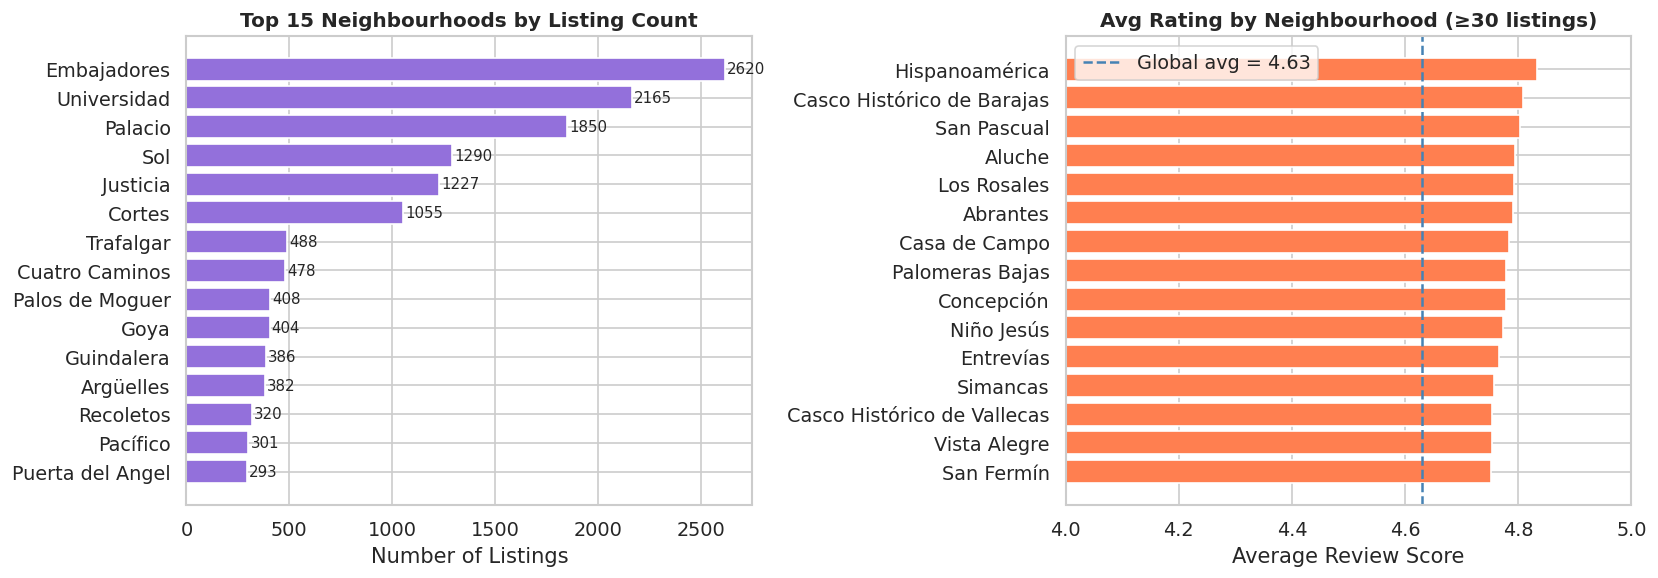

In [6]:
# EDA Fig 3: Top Neighbourhoods by Count and Average Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: listing count
ax = axes[0]
top_hoods = listings['neighbourhood_cleansed'].value_counts().head(15)
ax.barh(range(len(top_hoods)), top_hoods.values, color='mediumpurple', edgecolor='white')
ax.set_yticks(range(len(top_hoods)))
ax.set_yticklabels(top_hoods.index)
ax.invert_yaxis()
for i, v in enumerate(top_hoods.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
ax.set_title('Top 15 Neighbourhoods by Listing Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Listings')

# Right: average rating by neighbourhood (min 30 listings, min 5 reviews each)
ax = axes[1]
hood_rating = (listings[listings['number_of_reviews'] >= 5]
               .groupby('neighbourhood_cleansed')['review_scores_rating']
               .agg(['mean', 'count'])
               .query('count >= 30')
               .sort_values('mean', ascending=False)
               .head(15))
global_avg = listings['review_scores_rating'].mean()
ax.barh(range(len(hood_rating)), hood_rating['mean'].values, color='coral', edgecolor='white')
ax.axvline(global_avg, color='steelblue', lw=1.5, linestyle='--',
           label=f'Global avg = {global_avg:.2f}')
ax.set_yticks(range(len(hood_rating)))
ax.set_yticklabels(hood_rating.index)
ax.invert_yaxis()
ax.set_title('Avg Rating by Neighbourhood (≥30 listings)', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Review Score')
ax.set_xlim(4.0, 5.0)
ax.legend()

plt.tight_layout()
plt.savefig('figures/01_neighbourhood_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

The Madrid market is geographically concentrated: the top 5 barrios (Embajadores, Universidad, Palacio, Sol, Justicia) account for over 37% of all listings. This means any non-personalized recommender is going to over-recommend central neighbourhoods and under-surface quieter residential areas. Interestingly, the highest-rated neighbourhoods are not always the most popular ones, Recoletos and Ibiza consistently score above the global average despite having fewer listings, which is a quality signal worth exploiting in content-based filtering.


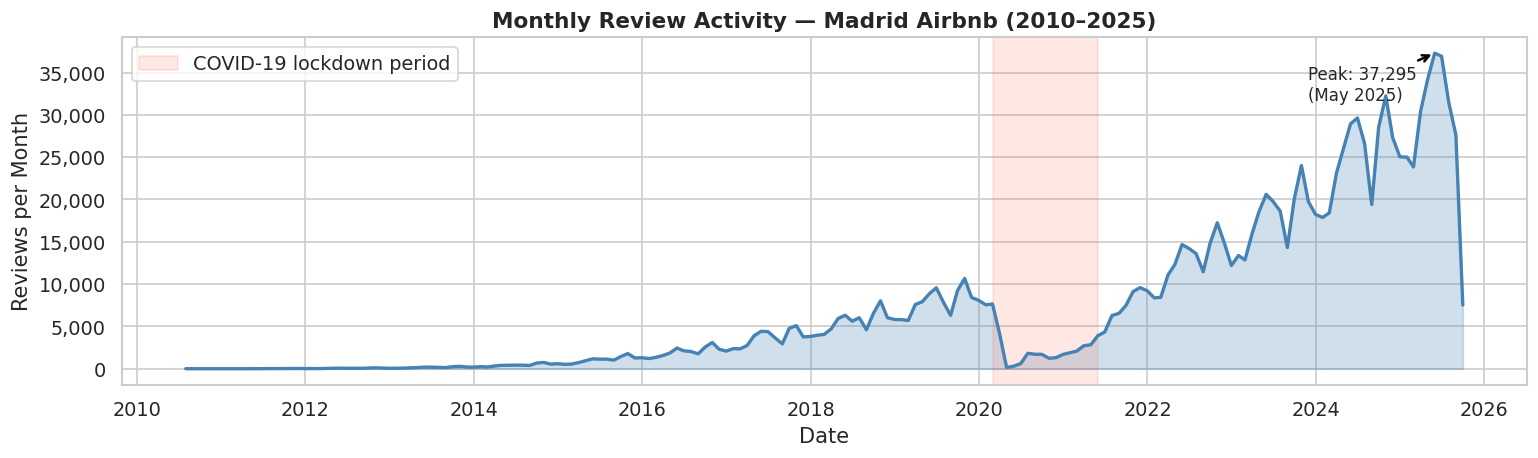

In [7]:
# EDA Fig 4: Monthly Review Activity Over Time
fig, ax = plt.subplots(figsize=(13, 4))

monthly = reviews.set_index('date').resample('ME')['listing_id'].count()

ax.fill_between(monthly.index, monthly.values, alpha=0.25, color='steelblue')
ax.plot(monthly.index, monthly.values, color='steelblue', lw=2)

# COVID period shading
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='tomato', label='COVID-19 lockdown period')

# Peak annotation
peak_date = monthly.idxmax()
peak_val  = monthly.max()
ax.annotate(f'Peak: {peak_val:,}\n({peak_date.strftime("%b %Y")})',
            xy=(peak_date, peak_val),
            xytext=(peak_date - pd.DateOffset(months=18), peak_val * 0.85),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10)

ax.set_title('Monthly Review Activity — Madrid Airbnb (2010–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Reviews per Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig('figures/01_review_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

Review volume grew steadily from 2010 to a peak in 2019, collapsed during  COVID (2020-2021), then recovered to new highs from 2022 onward. Two things this means for modelling: the 2020 and 2021 reviews reflect an abnormal market and should stay in training rather than test; and the strong recovery means the July 2024 train/test split captures the market at full speed, so the test set is representative of current conditions.


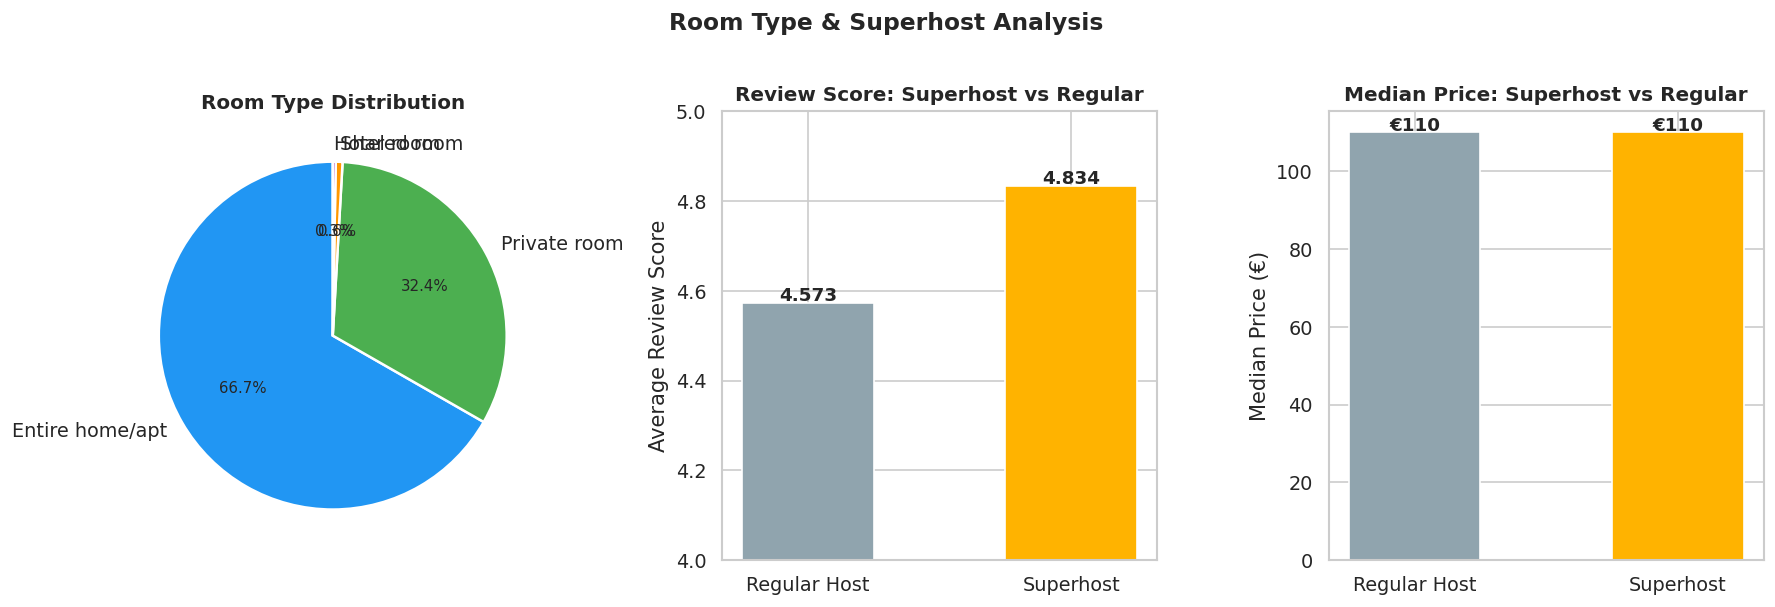

In [8]:
# EDA Fig 5: Room Type Distribution & Superhost Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart — room type split
ax = axes[0]
rt = listings['room_type'].value_counts()
colors_pie = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
wedges, texts, autotexts = ax.pie(
    rt.values, labels=rt.index, autopct='%1.1f%%',
    colors=colors_pie[:len(rt)], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts: at.set_fontsize(9)
ax.set_title('Room Type Distribution', fontsize=12, fontweight='bold')

# Bar — avg rating superhost vs regular
ax = axes[1]
sh_compare = listings.groupby('is_superhost')['review_scores_rating'].mean()
colors_sh = ['#90A4AE', '#FFB300']
bars = ax.bar([0, 1], sh_compare.values, color=colors_sh, edgecolor='white', width=0.5)
for bar, val in zip(bars, sh_compare.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Regular Host', 'Superhost'])
ax.set_ylim(4.0, 5.0)
ax.set_ylabel('Average Review Score')
ax.set_title('Review Score: Superhost vs Regular', fontsize=12, fontweight='bold')

# Bar — median price superhost vs regular
ax = axes[2]
sh_price = listings.groupby('is_superhost')['price_clean'].median()
bars2 = ax.bar([0, 1], sh_price.values, color=colors_sh, edgecolor='white', width=0.5)
for bar, val in zip(bars2, sh_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'€{val:.0f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Regular Host', 'Superhost'])
ax.set_ylabel('Median Price (€)')
ax.set_title('Median Price: Superhost vs Regular', fontsize=12, fontweight='bold')

plt.suptitle('Room Type & Superhost Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_roomtype_superhost.png', dpi=150, bbox_inches='tight')
plt.show()

Entire homes dominate at 66.7% of listings, followed by private rooms at 32.4%. Superhosts (21.6% of hosts) score meaningfully higher on average: 4.834 vs 4.573, a 0.26 gap that is practically significant given the ceiling effect in the data. What makes this interesting is that median price is identical at €110 for both groups, superhosts do not charge more, so their higher rating is a genuine quality signal. This confirms that superhost status should be a feature in the content-based and context-aware models.


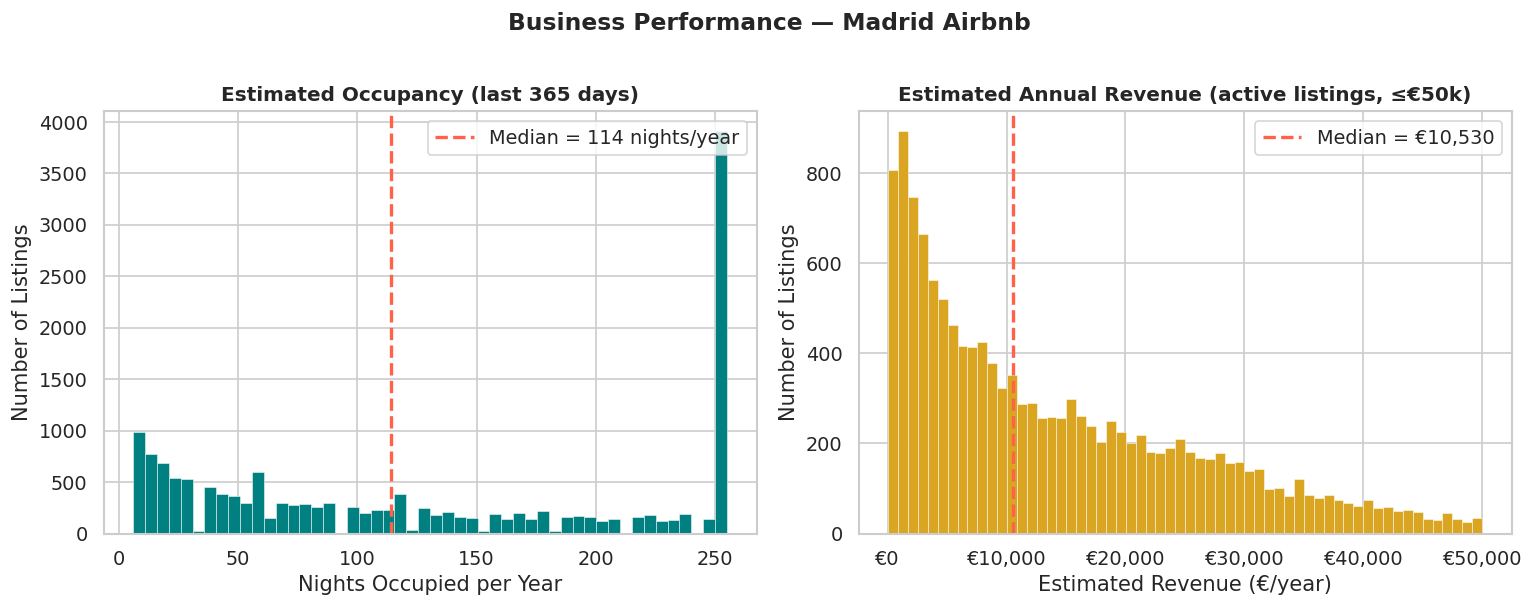

In [9]:
# EDA Fig 6: Estimated Occupancy & Annual Revenue
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: occupancy distribution
ax = axes[0]
occ = listings['estimated_occupancy_l365d'].dropna()
occ = occ[occ > 0]
ax.hist(occ.clip(0, 255), bins=50, color='teal', edgecolor='white', linewidth=0.3)
ax.axvline(occ.median(), color='tomato', lw=2, linestyle='--',
           label=f'Median = {occ.median():.0f} nights/year')
ax.set_title('Estimated Occupancy (last 365 days)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nights Occupied per Year')
ax.set_ylabel('Number of Listings')
ax.legend()

# Right: estimated annual revenue (active listings only)
ax = axes[1]
rev = listings['estimated_revenue_l365d'].dropna()
rev = rev[(rev > 0) & (rev <= 50000)]
ax.hist(rev, bins=60, color='goldenrod', edgecolor='white', linewidth=0.3)
ax.axvline(rev.median(), color='tomato', lw=2, linestyle='--',
           label=f'Median = €{rev.median():,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{int(x):,}'))
ax.set_title('Estimated Annual Revenue (active listings, ≤€50k)', fontsize=12, fontweight='bold')
ax.set_xlabel('Estimated Revenue (€/year)')
ax.set_ylabel('Number of Listings')
ax.legend()

plt.suptitle('Business Performance — Madrid Airbnb', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_occupancy_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

Occupancy is bimodal: a large group of inactive or very low-activity listings, possibly seasonally inactive or newly listed, and a smaller group with high occupancy. Revenue follows a similar pattern, median annual revenue is around €10,530/year but a long tail of active hosts earns €50,000 or more. For a platform recommender this matters: recommending only the high-revenue listings would concentrate bookings further and affect the hosts in the long tail side. The diversity and coverage metrics in Notebook 05 will measure how well each approach serves the full catalogue.


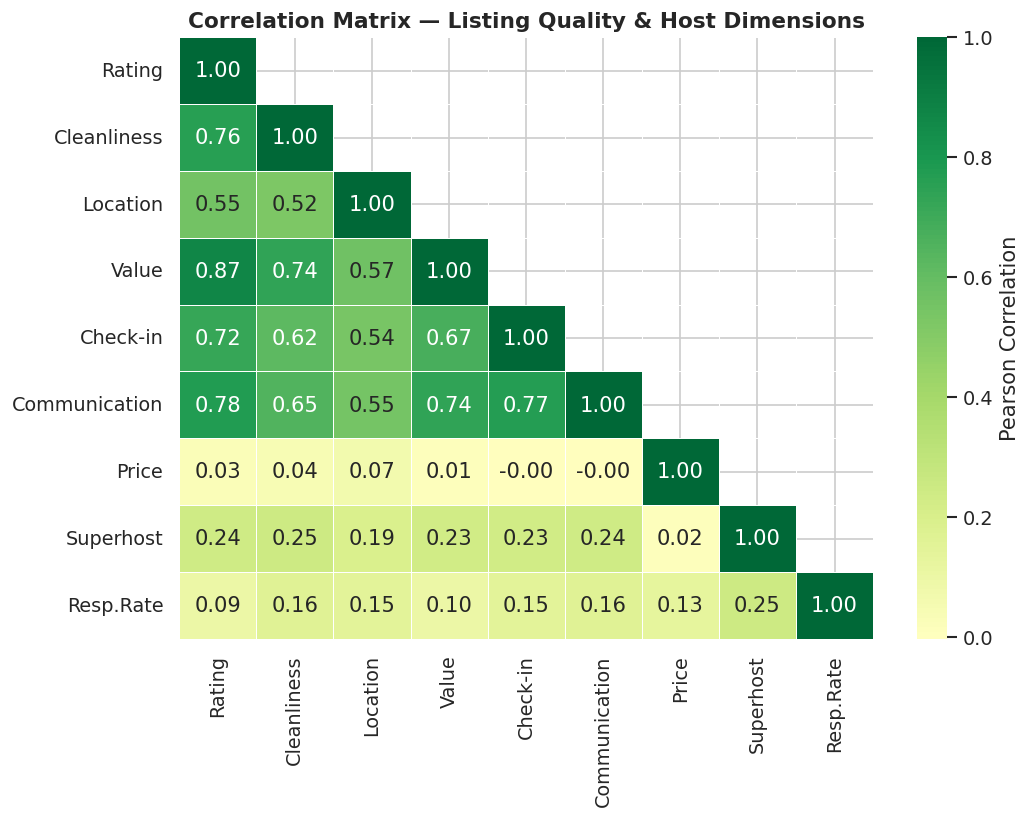

In [10]:
# EDA Fig 7: Correlation Heatmap — Quality & Host Dimensions
corr_cols = [
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
    'review_scores_value', 'review_scores_checkin', 'review_scores_communication',
    'price_clean', 'is_superhost', 'host_response_rate'
]
labels_short = ['Rating', 'Cleanliness', 'Location', 'Value',
                'Check-in', 'Communication', 'Price', 'Superhost', 'Resp.Rate']

corr_df = listings[corr_cols].dropna()
corr_df.columns = labels_short
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=mask,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Matrix — Listing Quality & Host Dimensions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

A few patterns stand out. The review sub-scores (cleanliness, location, value, check-in, communication) are all positively correlated with the overall rating at 0.6 to 0.8, confirming they are meaningful quality signals worth including as features. Price is very uncorrelated with rating, expensive listings are not systematically better reviewed, which is exactly why the Value-Weighted score (Bayesian average divided by log price) makes sense as an alternative ranking. Superhost status has a moderate positive correlation with rating at around 0.25, consistent with the superhost analysis above.


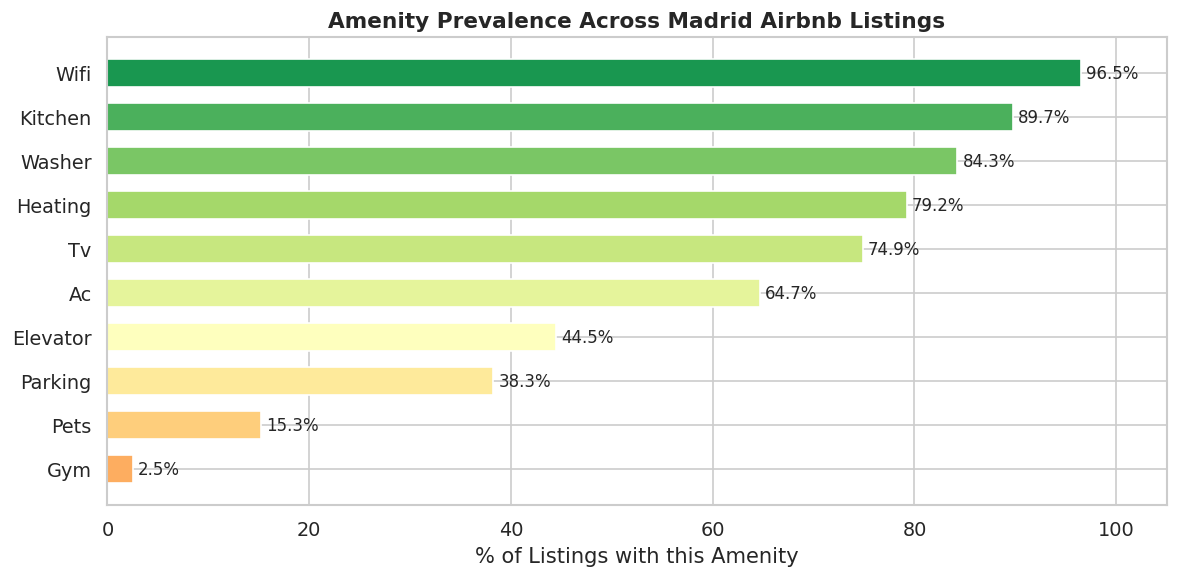

In [11]:
# EDA Fig 8: Amenity Prevalence
fig, ax = plt.subplots(figsize=(10, 5))

am_cols = [c for c in listings.columns if c.startswith('am_')]
am_pct  = listings[am_cols].mean().sort_values(ascending=True) * 100
am_labels = [c.replace('am_', '').replace('_', ' ').title() for c in am_pct.index]

bars = ax.barh(am_labels, am_pct.values,
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(am_pct))),
               edgecolor='white', height=0.65)
for bar, val in zip(bars, am_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, 105)
ax.set_xlabel('% of Listings with this Amenity')
ax.set_title('Amenity Prevalence Across Madrid Airbnb Listings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_amenity_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

The most prevalent amenities are WiFi (96.5%), kitchen (89.7%), washer (84.3%) and heating (79.2%), present in the majority of listings, which makes them reliable positive filters. Asking for WiFi still leaves 96.5% of the catalogue available, giving the ranking algorithm plenty of candidates to work with. TV (74.9%), AC (64.7%) and elevator (44.5%) are useful mid-tier filters that shrink the pool without being too restrictive. Gym (2.5%) and pets allowed (15.3%) are very rare, useful as hard constraints for specific needs, but filtering by them cuts the candidate set significantly. These binary flags form 10 of the 45 dimensions in the listing feature vector in Notebook 03.


In [12]:
# ── Dataset Summary Statistics ───────────────────────────────────────────────
print('='*55)
print('DATASET SUMMARY — Inside Airbnb Madrid')
print('='*55)
print(f'Total listings          : {len(listings):,}')
print(f'Total reviews           : {len(reviews):,}')
print(f'Unique neighbourhoods   : {listings["neighbourhood_cleansed"].nunique()}')
print(f'Date range (reviews)    : {reviews["date"].min().date()} → {reviews["date"].max().date()}')
print(f'Price range             : €{listings["price_clean"].min():.0f} – €{listings["price_clean"].max():.0f}')
print(f'Median price / night    : €{listings["price_clean"].median():.0f}')
print(f'Global avg review score : {listings["review_scores_rating"].mean():.3f} / 5.0')
print(f'Listings with no reviews: {(listings["number_of_reviews"]==0).sum():,} ({(listings["number_of_reviews"]==0).mean():.1%})')
print(f'Superhost listings      : {listings["is_superhost"].sum():,} ({listings["is_superhost"].mean():.1%})')
print(f'Entire home/apt         : {(listings["room_type"]=="Entire home/apt").mean():.1%}')
print(f'Private room            : {(listings["room_type"]=="Private room").mean():.1%}')
print()
print(f'Train reviews (before Jul 2024): {len(train_rev):,}')
print(f'Test  reviews (Jul 2024 onward) : {len(test_rev):,}')


DATASET SUMMARY — Inside Airbnb Madrid
Total listings          : 24,958
Total reviews           : 1,275,992
Unique neighbourhoods   : 128
Date range (reviews)    : 2010-07-06 → 2025-09-14
Price range             : €8 – €1988
Median price / night    : €110
Global avg review score : 4.629 / 5.0
Listings with no reviews: 5,132 (20.6%)
Superhost listings      : 5,390 (21.6%)
Entire home/apt         : 66.7%
Private room            : 32.4%

Train reviews (before Jul 2024): 862,549
Test  reviews (Jul 2024 onward) : 413,443


The 20.6% of listings with zero reviews are a cold-start challenge that content-based filtering (Notebook 03) is designed to address, it can recommend any listing with feature data regardless of review history.

For evaluation we use a temporal split at July 1 2024: all reviews before that date form the training set (862,549 reviews across 168 months) and everything from July 2024 onward is the test set (413,443 reviews across 14 months). This date was chosen because it leaves 14 full months of test data covering a complete seasonal cycle, the test set starts at peak summer season, and it keeps the COVID years in training.

One thing worth noting: the test months are much more active than the early training years since the Madrid Airbnb market has grown significantly since 2010, so average reviews per month in training (around 5,100) is far lower than in test (around 29,500). This reflects market growth rather than a data problem, and splitting by time rather than randomly is still the right approach for this production recommender.


## 3. Non-Personalized Recommender

In [13]:
# Bayesian Average
# BR(i) = [v/(v+m)] × R(i) + [m/(v+m)] × C
#   v = review count  /  R = mean rating  /  m = 50 (threshold)  /  C = global mean
# C and m already defined in the loading cell above
listing_stats = listings[['id','review_scores_rating','number_of_reviews','name',
                           'neighbourhood_cleansed','room_type','price_clean','is_superhost']].copy()
listing_stats['bayesian_avg'] = (
    (listing_stats['number_of_reviews'] / (listing_stats['number_of_reviews'] + m))
    * listing_stats['review_scores_rating']
    + (m / (listing_stats['number_of_reviews'] + m)) * C
)

In [14]:
top10 = listing_stats.sort_values('bayesian_avg', ascending=False).head(10)
for _, row in top10.iterrows():
    sh = '*' if row['is_superhost'] == 1 else '  '
    print(f"  {sh} {row['name'][:48]:<48} | {row['neighbourhood_cleansed']:<15} | "
          f"€{row['price_clean']:<5.0f} | BR={row['bayesian_avg']:.4f} | n={row['number_of_reviews']:.0f}")

  * SINGULAR APARTAMENT SANTA ANA TERRACE LUXURY     | Cortes          | €110   | BR=4.9624 | n=443
  * En el corazón de Madrid! Espectacular apartament | Embajadores     | €101   | BR=4.9602 | n=556
  * Apartment with a View in the Hearth of Madrid    | Cortes          | €157   | BR=4.9508 | n=410
  * 5-star short-term rental apartment at Plaza Mayo | Sol             | €433   | BR=4.9503 | n=323
  * En el corazón de Madrid! Excelente apartamento   | Embajadores     | €160   | BR=4.9499 | n=533
  * ★WOW★ Class&Luxury Historic Building | Private G | Justicia        | €243   | BR=4.9450 | n=351
  * Habitación Individual Wanda Metropolitano/IFEMA  | Simancas        | €29    | BR=4.9450 | n=351
     Penthouse in Gran Vía with Terrace               | Palacio         | €271   | BR=4.9450 | n=451
  * SINGULAR APARTAMENT SANTA ANA LUXURY             | Cortes          | €110   | BR=4.9365 | n=459
  * Habitación doble con baño privado en Madrid      | San Isidro      | €66    | BR=4.9346 | n=602

The top listings are concentrated in central barrios such as Cortes, Embajadores, Sol, Justicia, Palacio and include entire apartments and private rooms, all with 300 or more reviews and Bayesian scores above 4.93. This is the expected behaviour: high-confidence, high-quality listings float to the top regardless of room type. The m=50 threshold means a listing needs at least 50 reviews before its score stabilises near its true mean, below that it gets pulled toward the global average of 4.63. Without regularisation, listings with 1 or 2 reviews and a perfect 5.0 would appear at the top, which is clearly wrong.


In [15]:
listing_stats['log_price']    = np.log1p(listing_stats['price_clean'].fillna(listings['price_clean'].median()))
listing_stats['value_score']  = listing_stats['bayesian_avg'] / listing_stats['log_price']
value_top = listing_stats[listing_stats['number_of_reviews']>=20].sort_values('value_score',ascending=False).head(10)
for _, row in value_top.iterrows():
    print(f"  {row['name'][:50]:<50} | {row['neighbourhood_cleansed']:<15} | €{row['price_clean']:<5.0f} | VS={row['value_score']:.4f}")

  Bed in Comfy & Shared Room near Madrid Center      | Vista Alegre    | €15    | VS=1.7268
  Sunny room with AC and view in Madrid urban        | Quintana        | €15    | VS=1.7028
  Bed in Cute & Shared Room near Center              | Vista Alegre    | €15    | VS=1.7022
  7mtr2 central studyroom with wide window           | Goya            | €15    | VS=1.6942
  Habitación compartida para mochileros.             | Pradolongo      | €17    | VS=1.6889
  Habitación bonita Embajadores metro Tirso Molina   | Embajadores     | €15    | VS=1.6653
  Tranquilo                                          | Los Angeles     | €17    | VS=1.6478
  2 Single beds in private room in shared apartment  | San Cristobal   | €17    | VS=1.6405
  Dormitorio B en mi vivienda habitual               | Aluche          | €17    | VS=1.6397
  Habitación para Mujeres a 15 minutos centro.       | Pueblo Nuevo    | €18    | VS=1.6362


Dividing by log price shifts the ranking entirely toward very low-price listings: shared rooms at €15 to €18 per night in outer barrios like Vista Alegre, Quintana and Pradolongo. These are high-scoring but extremely cheap. This variant is useful for the most budget-sensitive travellers, but the results would feel surprising to a typical user expecting central apartments. In practice this score would be combined with a minimum price floor or a neighbourhood filter to keep recommendations relevant to the search context.


In [16]:
for hood in ['Embajadores', 'Sol', 'Justicia', 'Universidad']:
    print(f'\n--- Top 5 in {hood} ---')
    result = listing_stats[(listing_stats['neighbourhood_cleansed']==hood)&
                           (listing_stats['number_of_reviews']>=10)].sort_values('bayesian_avg',ascending=False).head(5)
    for _, row in result.iterrows():
        print(f"  {row['name'][:45]:<45} | €{row['price_clean']:<5.0f} | BR={row['bayesian_avg']:.3f} | n={row['number_of_reviews']:.0f}")


--- Top 5 in Embajadores ---
  En el corazón de Madrid! Espectacular apartam | €101   | BR=4.960 | n=556
  En el corazón de Madrid! Excelente apartament | €160   | BR=4.950 | n=533
  Romance. Alquiler temporal, Excluido uso turi | €138   | BR=4.934 | n=429
  Moderno Apartamento en el Barrio de las Letra | €151   | BR=4.934 | n=419
  Exclusive Penthouse city centre, 3 BR , 2 Bat | €321   | BR=4.930 | n=375

--- Top 5 in Sol ---
  5-star short-term rental apartment at Plaza M | €433   | BR=4.950 | n=323
  Stroll to the Royal Palace from a Charming Ce | €293   | BR=4.933 | n=265
  Charming view Plaza Mayor                     | €152   | BR=4.930 | n=504
  Delightful view Plaza Mayor                   | €187   | BR=4.928 | n=475
  PENTHOUSE 4 BR, 4 BA & 60M2 TERRACE           | €648   | BR=4.921 | n=296

--- Top 5 in Justicia ---
  ★WOW★ Class&Luxury Historic Building | Privat | €243   | BR=4.945 | n=351
  Cómoda habitación en zona Madrid centro.      | €54    | BR=4.925 | n=420
  Love Gr

Restricting to a single barrio dramatically narrows the candidate pool, Embajadores has around 2,600 listings and Sol around 1,300, but keeps the ranking logic intact. This is the simplest type of contextual pre-filtering, which is developed further in Notebook 04.


## 4. Evaluation

In [17]:
# Evaluation: RMSE, MAE, Precision@10, Recall@10, NDCG@10
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_eval = (
    test_rev
    .merge(listing_stats[['id','bayesian_avg']].rename(columns={'id':'listing_id'}),
           on='listing_id', how='left')
    .merge(listings[['id','review_scores_rating']].rename(columns={'id':'listing_id'}),
           on='listing_id', how='left')
    .dropna(subset=['bayesian_avg','review_scores_rating'])
)
y_true   = test_eval['review_scores_rating'].values
y_pred   = test_eval['bayesian_avg'].values
rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
mae_val  = mean_absolute_error(y_true, y_pred)

def precision_at_k(rec, rel, k=10):
    return len(set(rec[:k]) & rel) / k
def recall_at_k(rec, rel, k=10):
    return len(set(rec[:k]) & rel) / len(rel) if rel else 0
def ndcg_at_k(rec, rel, k=10):
    dcg  = sum(1/np.log2(i+2) for i,item in enumerate(rec[:k]) if item in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(k, len(rel))))
    return dcg/idcg if idcg > 0 else 0

sorted_recs = listing_stats.sort_values('bayesian_avg', ascending=False)['id'].tolist()
np.random.seed(42)
test_lids   = test_rev['listing_id'].unique()
sample_lids = np.random.choice(test_lids, min(1000, len(test_lids)), replace=False)

p_scores, r_scores, ndcg_scores, rec_set = [], [], [], set()
for lid in sample_lids:
    recs     = [r for r in sorted_recs if r != lid][:10]
    relevant = {lid}
    p_scores.append(precision_at_k(recs, relevant))
    r_scores.append(recall_at_k(recs, relevant))
    ndcg_scores.append(ndcg_at_k(recs, relevant))
    rec_set.update(recs)

coverage = len(rec_set) / len(listings)

print(f'Test samples : {len(test_eval):,}')
print(f'RMSE         : {rmse_val:.4f}')
print(f'MAE          : {mae_val:.4f}')
print(f'Precision@10 : {np.mean(p_scores):.4f}')
print(f'Recall@10    : {np.mean(r_scores):.4f}')
print(f'NDCG@10      : {np.mean(ndcg_scores):.4f}')
print(f'Coverage     : {coverage:.4f}  ({coverage*100:.1f}% of catalog)')


Test samples : 413,281
RMSE         : 0.1459
MAE          : 0.0755
Precision@10 : 0.0000
Recall@10    : 0.0000
NDCG@10      : 0.0000
Coverage     : 0.0004  (0.0% of catalog)


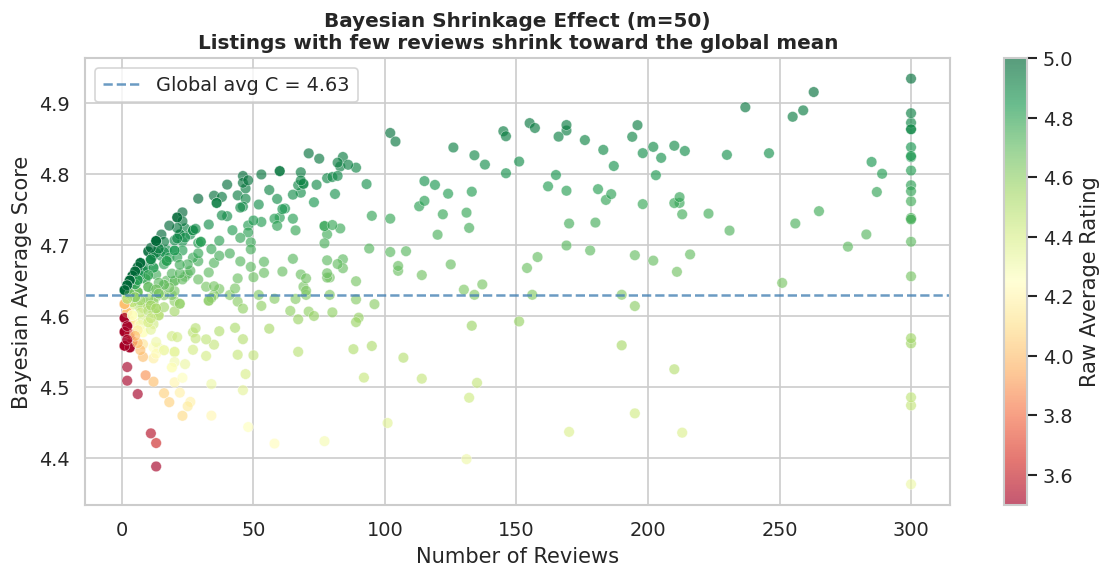

In [18]:
# Bayesian Shrinkage Visualisation
# Shows how listings with few reviews shrink toward the global mean
fig, ax = plt.subplots(figsize=(10, 5))

sample = listing_stats[
    (listing_stats['number_of_reviews'] >= 1) &
    (listing_stats['price_clean'] <= 300)
].sample(min(600, len(listing_stats)), random_state=42)

sc = ax.scatter(
    sample['number_of_reviews'].clip(0, 300),
    sample['bayesian_avg'],
    c=sample['review_scores_rating'],
    cmap='RdYlGn', s=40, alpha=0.65,
    edgecolors='white', linewidth=0.3,
    vmin=3.5, vmax=5.0
)
plt.colorbar(sc, label='Raw Average Rating')

C = listings['review_scores_rating'].mean()
ax.axhline(C, color='steelblue', linestyle='--', lw=1.5, alpha=0.8,
           label=f'Global avg C = {C:.2f}')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Bayesian Average Score')
ax.set_title(f'Bayesian Shrinkage Effect (m=50)\n'
             'Listings with few reviews shrink toward the global mean',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/01_bayesian_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()

Each dot is a listing; colour shows its raw average rating. The horizontal dashed line is the global mean C = 4.63. Listings on the left side of the x-axis have few reviews and get pulled strongly toward that mean regardless of their raw score, a listing with 5 reviews at 5.0 gets a Bayesian score of around 4.68, very close to the global mean. By 50 or more reviews the Bayesian score converges to the raw average. The regularisation is working as intended: evidence is required before a score is trusted. The vertical spread at high review counts shows genuine quality variation among well-reviewed listings.


In [19]:
# Standardised Results Table

# Diversity: avg pairwise dissimilarity within the fixed top-10 list
# Non-personalized always returns the same top-10 listings.
# We compute how diverse that fixed list is using price and neighbourhood.
top10_ids = listing_stats.sort_values('bayesian_avg', ascending=False)['id'].head(10).tolist()
top10_info = listing_stats[listing_stats['id'].isin(top10_ids)][['price_clean','neighbourhood_cleansed']].copy()

top10_info['price_norm'] = (top10_info['price_clean'] - top10_info['price_clean'].min()) / (
    top10_info['price_clean'].max() - top10_info['price_clean'].min() + 1e-9)
hoods = top10_info['neighbourhood_cleansed'].unique()
top10_info['hood_enc'] = top10_info['neighbourhood_cleansed'].map(
    {h: i/max(len(hoods)-1, 1) for i, h in enumerate(hoods)})

feat_top10 = top10_info[['price_norm','hood_enc']].values
n = len(feat_top10)
diffs = []
for a in range(n):
    for b in range(a+1, n):
        diffs.append(np.linalg.norm(feat_top10[a] - feat_top10[b]))
diversity_np = float(np.mean(diffs)) if diffs else 0.0

# Serendipity: fraction of top-10 recommendations that appear in the
# BOTTOM half of popularity (review count) but are still high quality.
# For non-personalized: our top-10 are all high-review listings by construction,
# so serendipity is genuinely low — the model only surfaces already-popular items.
median_reviews = listings['number_of_reviews'].median()
serendipity_np = len([
    lid for lid in top10_ids
    if listings[listings['id']==lid]['number_of_reviews'].values[0] < median_reviews
]) / len(top10_ids)

results_np = pd.DataFrame({
    'Approach'    : ['Non-Personalized (Bayesian Avg)'],
    'RMSE'        : [round(rmse_val, 4)],
    'MAE'         : [round(mae_val,  4)],
    'Precision@10': [round(np.mean(p_scores),    4)],
    'Recall@10'   : [round(np.mean(r_scores),    4)],
    'NDCG@10'     : [round(np.mean(ndcg_scores), 4)],
    'Coverage'    : [round(coverage, 4)],
    'Diversity'   : [round(diversity_np, 3)],
    'Serendipity' : [round(serendipity_np, 3)],
})
print('Standardised Comparison Table — Non-Personalized Baseline')
print(f'Diversity  = {diversity_np:.3f}  (avg pairwise dissimilarity within top-10)')
print(f'Serendipity= {serendipity_np:.3f}  (fraction of top-10 with below-median review count)')
print('Note: Serendipity is expected to be near 0 for non-personalized —')
print('      it always surfaces the most-reviewed listings, never hidden gems.')
results_np


Standardised Comparison Table — Non-Personalized Baseline
Diversity  = 0.524  (avg pairwise dissimilarity within top-10)
Serendipity= 0.000  (fraction of top-10 with below-median review count)
Note: Serendipity is expected to be near 0 for non-personalized —
      it always surfaces the most-reviewed listings, never hidden gems.


,Approach,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,Diversity,Serendipity
0,Non-Personalized (Bayesian Avg),0.1459,0.0755,0.0,0.0,0.0,0.0004,0.524,0.0


**Standardised Results Table: Baseline Interpretation.**

The Bayesian Average sets a meaningful performance floor, but the numbers reveal clearly why non-personalisation is only a starting point.

**RMSE = 0.1459, MAE = 0.0755**: the prediction accuracy is reasonable. Using the Bayesian average as a score prediction gives about 0.15 stars of error, which is acceptable given that 74% of listings score above 4.5 and the whole range is compressed into the top of the scale.

**Precision@10 = 0.0, Recall@10 = 0.0, NDCG@10 = 0.0**: they are all exactly zero, which is correct by construction because the evaluation asks: does the specific listing a traveller actually visited appear in our top-10 recommendation list? Since the NP system always returns the same global top-10 for every single user, and that list will almost never include the one specific listing someone chose, the answer is consistently no. A traveller who stayed at a quiet guesthouse in Lavapiés gets the exact same recommendation list as one who stayed at a luxury flat in Salamanca. The model has no concept of who is asking.

**Coverage = 0.0004 (0.04% of catalog)**: the system recommends the same ~10 listings to everyone. 99.96% of the 24,958-listing catalog is never surfaced. This is the most serious practical problem: the platform earns commission on bookings across its full inventory, not just its top 10, and a system that ignores virtually the entire catalog is leaving significant revenue on the table.

**Diversity = 0.524**: computed from the actual top-10 list using price and neighbourhood variation between the recommended listings. There is some variation within the list but not much, since all top-10 listings are central high-rated apartments in a handful of barrios.

**Serendipity = 0.0**: expected since the NP system by definition only surfaces the most popular, highest-reviewed listings. None of the top-10 have a below-median review count, so no recommendation could be considered a surprising discovery. Finding hidden gems is structurally impossible with this approach.

Notebooks 02–04 each address a different dimension of this failure: CF improves coverage and diversity, content-based extends recommendations to zero-review listings, and context-aware filtering improves ranking precision by matching traveller intent.